In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load electricity generation data
data_folder = Path('./data/')
df = pd.read_excel(data_folder / 'Electricity_Generation_By_Source_Ontario.xlsx')
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

                      _      2005      2006      2007      2008      2009  \
0  Hydro / Wave / Tidal  32555.29  32555.29  32555.29  32555.29  32555.29   
1                  Wind   3072.78   3072.78   3072.78   3072.78   3072.78   
2  Biomass / Geothermal    735.10    735.10    735.10    735.10    735.10   
3                 Solar    115.74    115.74    115.74    115.74    115.74   
4               Uranium  81975.00  81975.00  81975.00  81975.00  81975.00   
5           Coal & Coke  28734.08  23808.08  27468.72  22638.21  10461.15   
6           Natural Gas  16885.54  16885.54  16885.54  16885.54  16885.54   
7                   Oil     73.47     73.47     73.47     73.47     73.47   

       2010      2011      2012      2013  ...       2041       2042  \
0  32555.29  34907.29  33887.14  37936.09  ...   39474.29   39452.22   
1   3072.78   3162.68   4007.37   3876.91  ...   75604.97   82983.68   
2    735.10    607.89    672.86    586.34  ...     968.66     955.15   
3    115.74    256

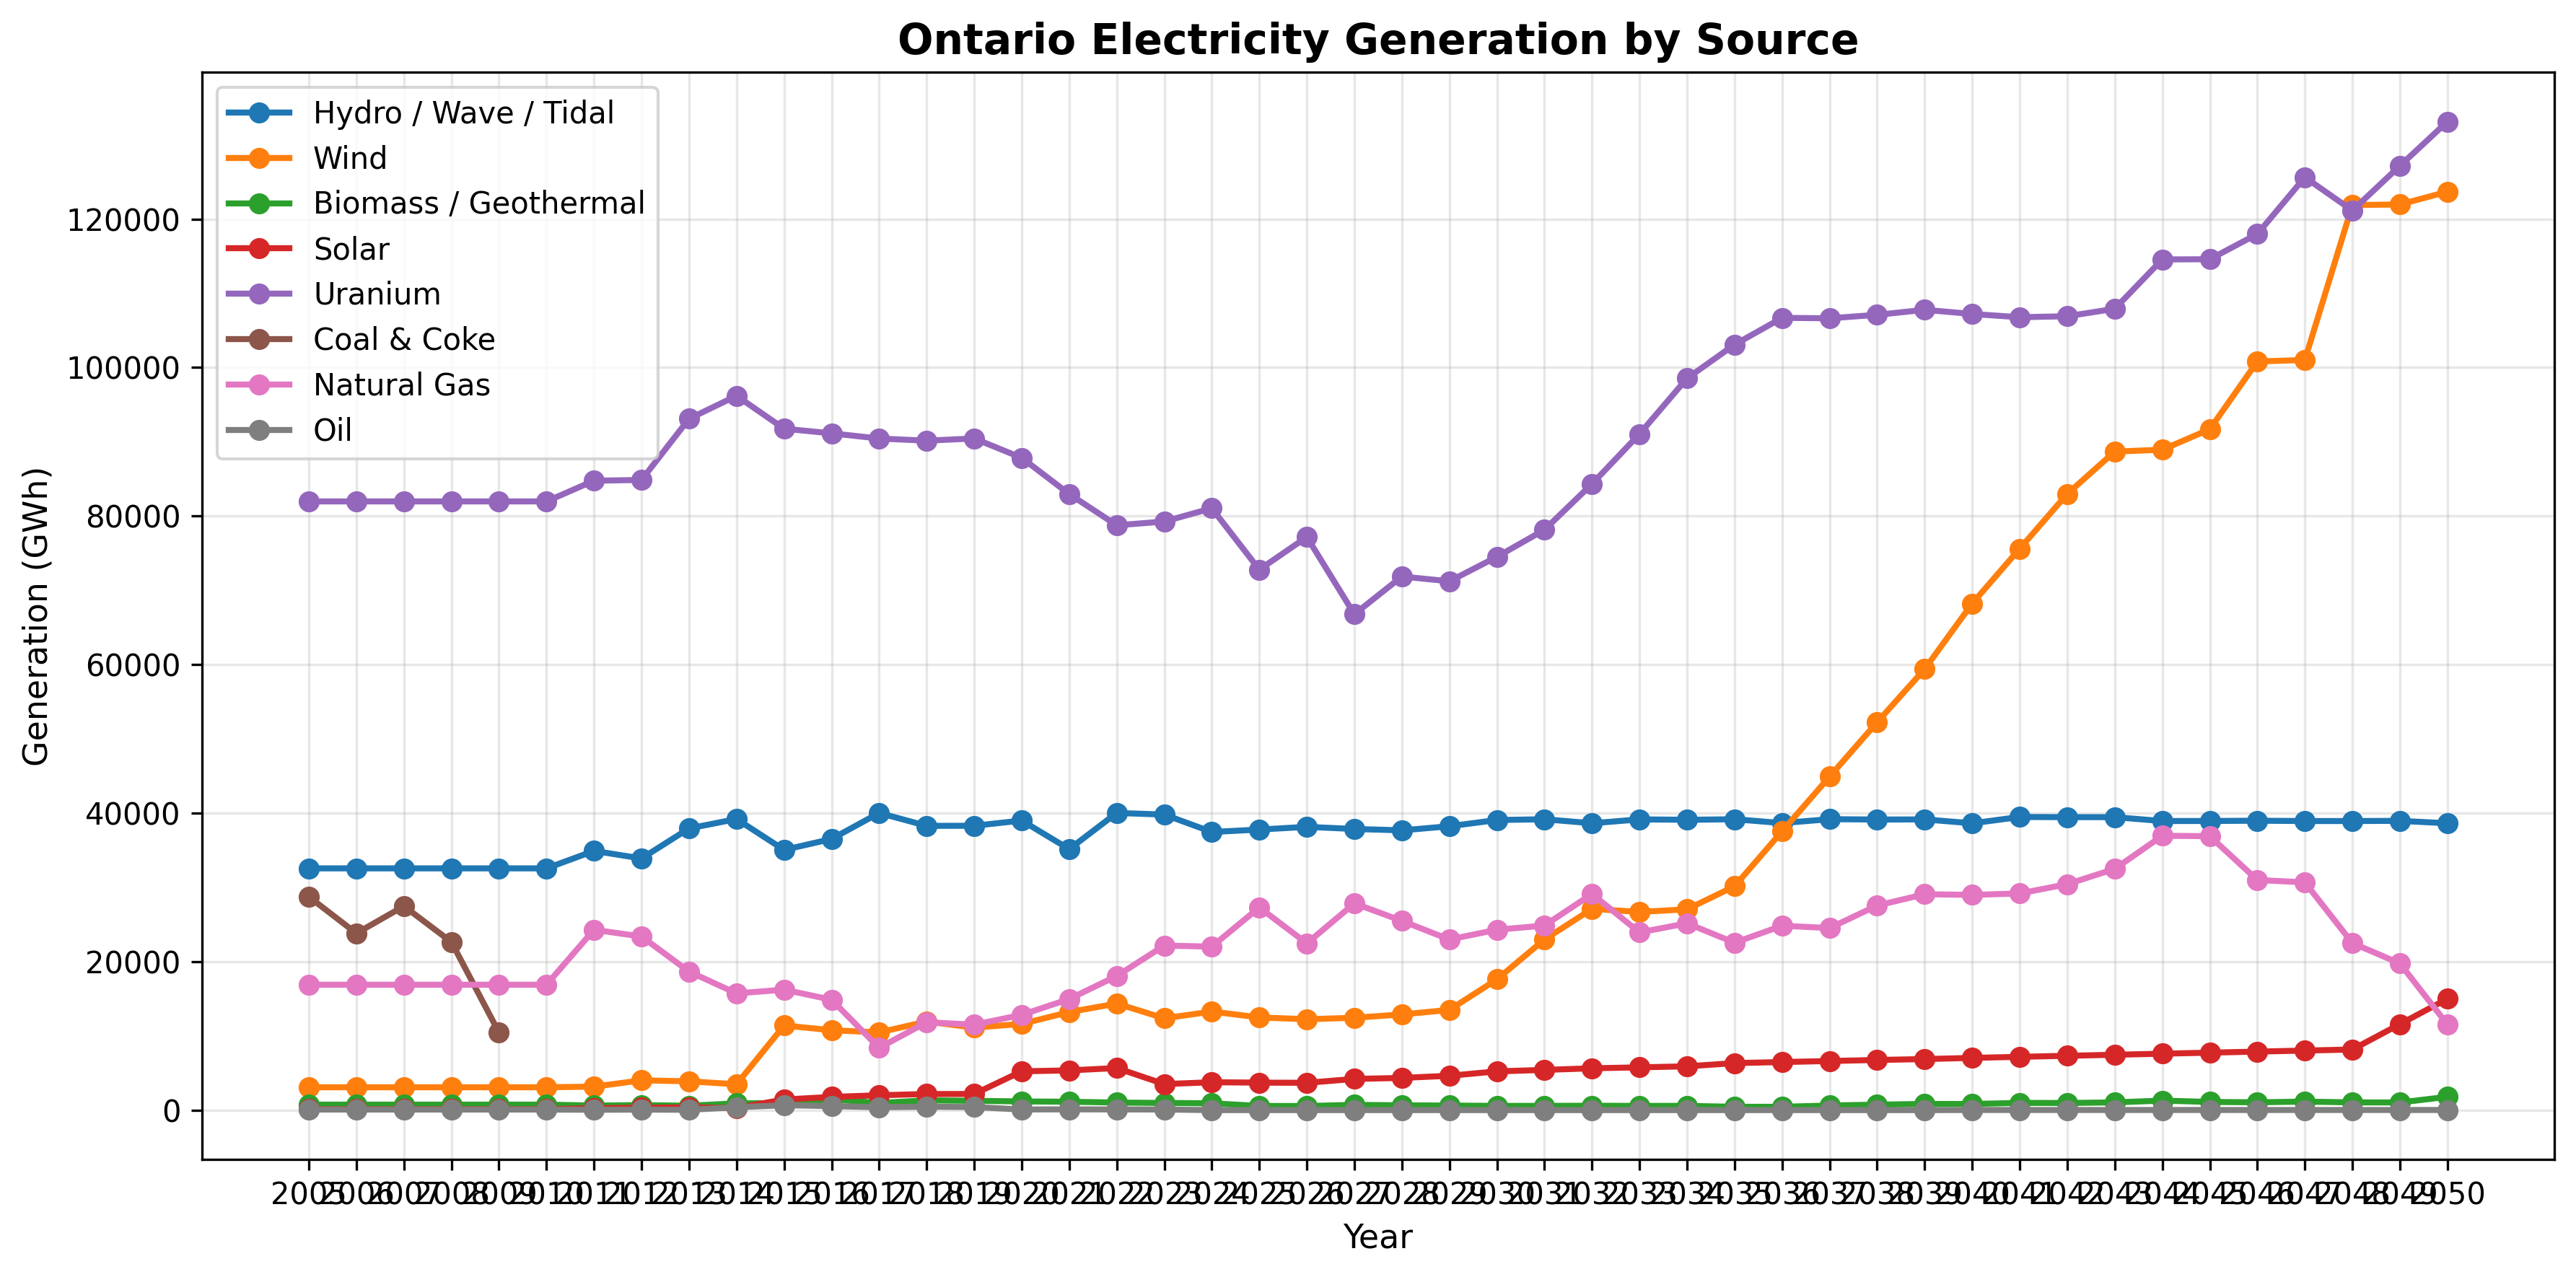

✓ Graph saved


In [18]:
# Simple line graph
df_plot = df.set_index(df.columns[0])

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

for source in df_plot.index:
    ax.plot(df_plot.columns, df_plot.loc[source], marker='o', linewidth=2, label=source)

ax.set_title('Ontario Electricity Generation by Source', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Generation (GWh)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_folder / 'Electricity_Generation_By_Source_Ontario.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graph saved")

Yearly Demand:
    Year  Total_Demand
0   2002    104773.619
1   2003    157982.144
2   2004    162925.342
3   2005    167153.184
4   2006    162442.513
5   2007    164491.422
6   2008    170876.581
7   2009    154300.535
8   2010    157360.156
9   2011    154319.233
10  2012    155905.911
11  2013    158542.864
12  2014    158273.142
13  2015    159031.052
14  2016    158174.232
15  2017    150578.393
16  2018    155631.773
17  2019    154455.959
18  2020    152173.361
19  2021    150607.860
20  2022    154593.808
21  2023    152796.391
22  2024    158303.840
23  2025    165511.186
24  2026     62691.931

Merged data:
    Year  Hydro / Wave / Tidal      Wind  Biomass / Geothermal    Solar  \
0   2005              32555.29   3072.78                735.10   115.74   
1   2006              32555.29   3072.78                735.10   115.74   
2   2007              32555.29   3072.78                735.10   115.74   
3   2008              32555.29   3072.78                735.10   115.74  

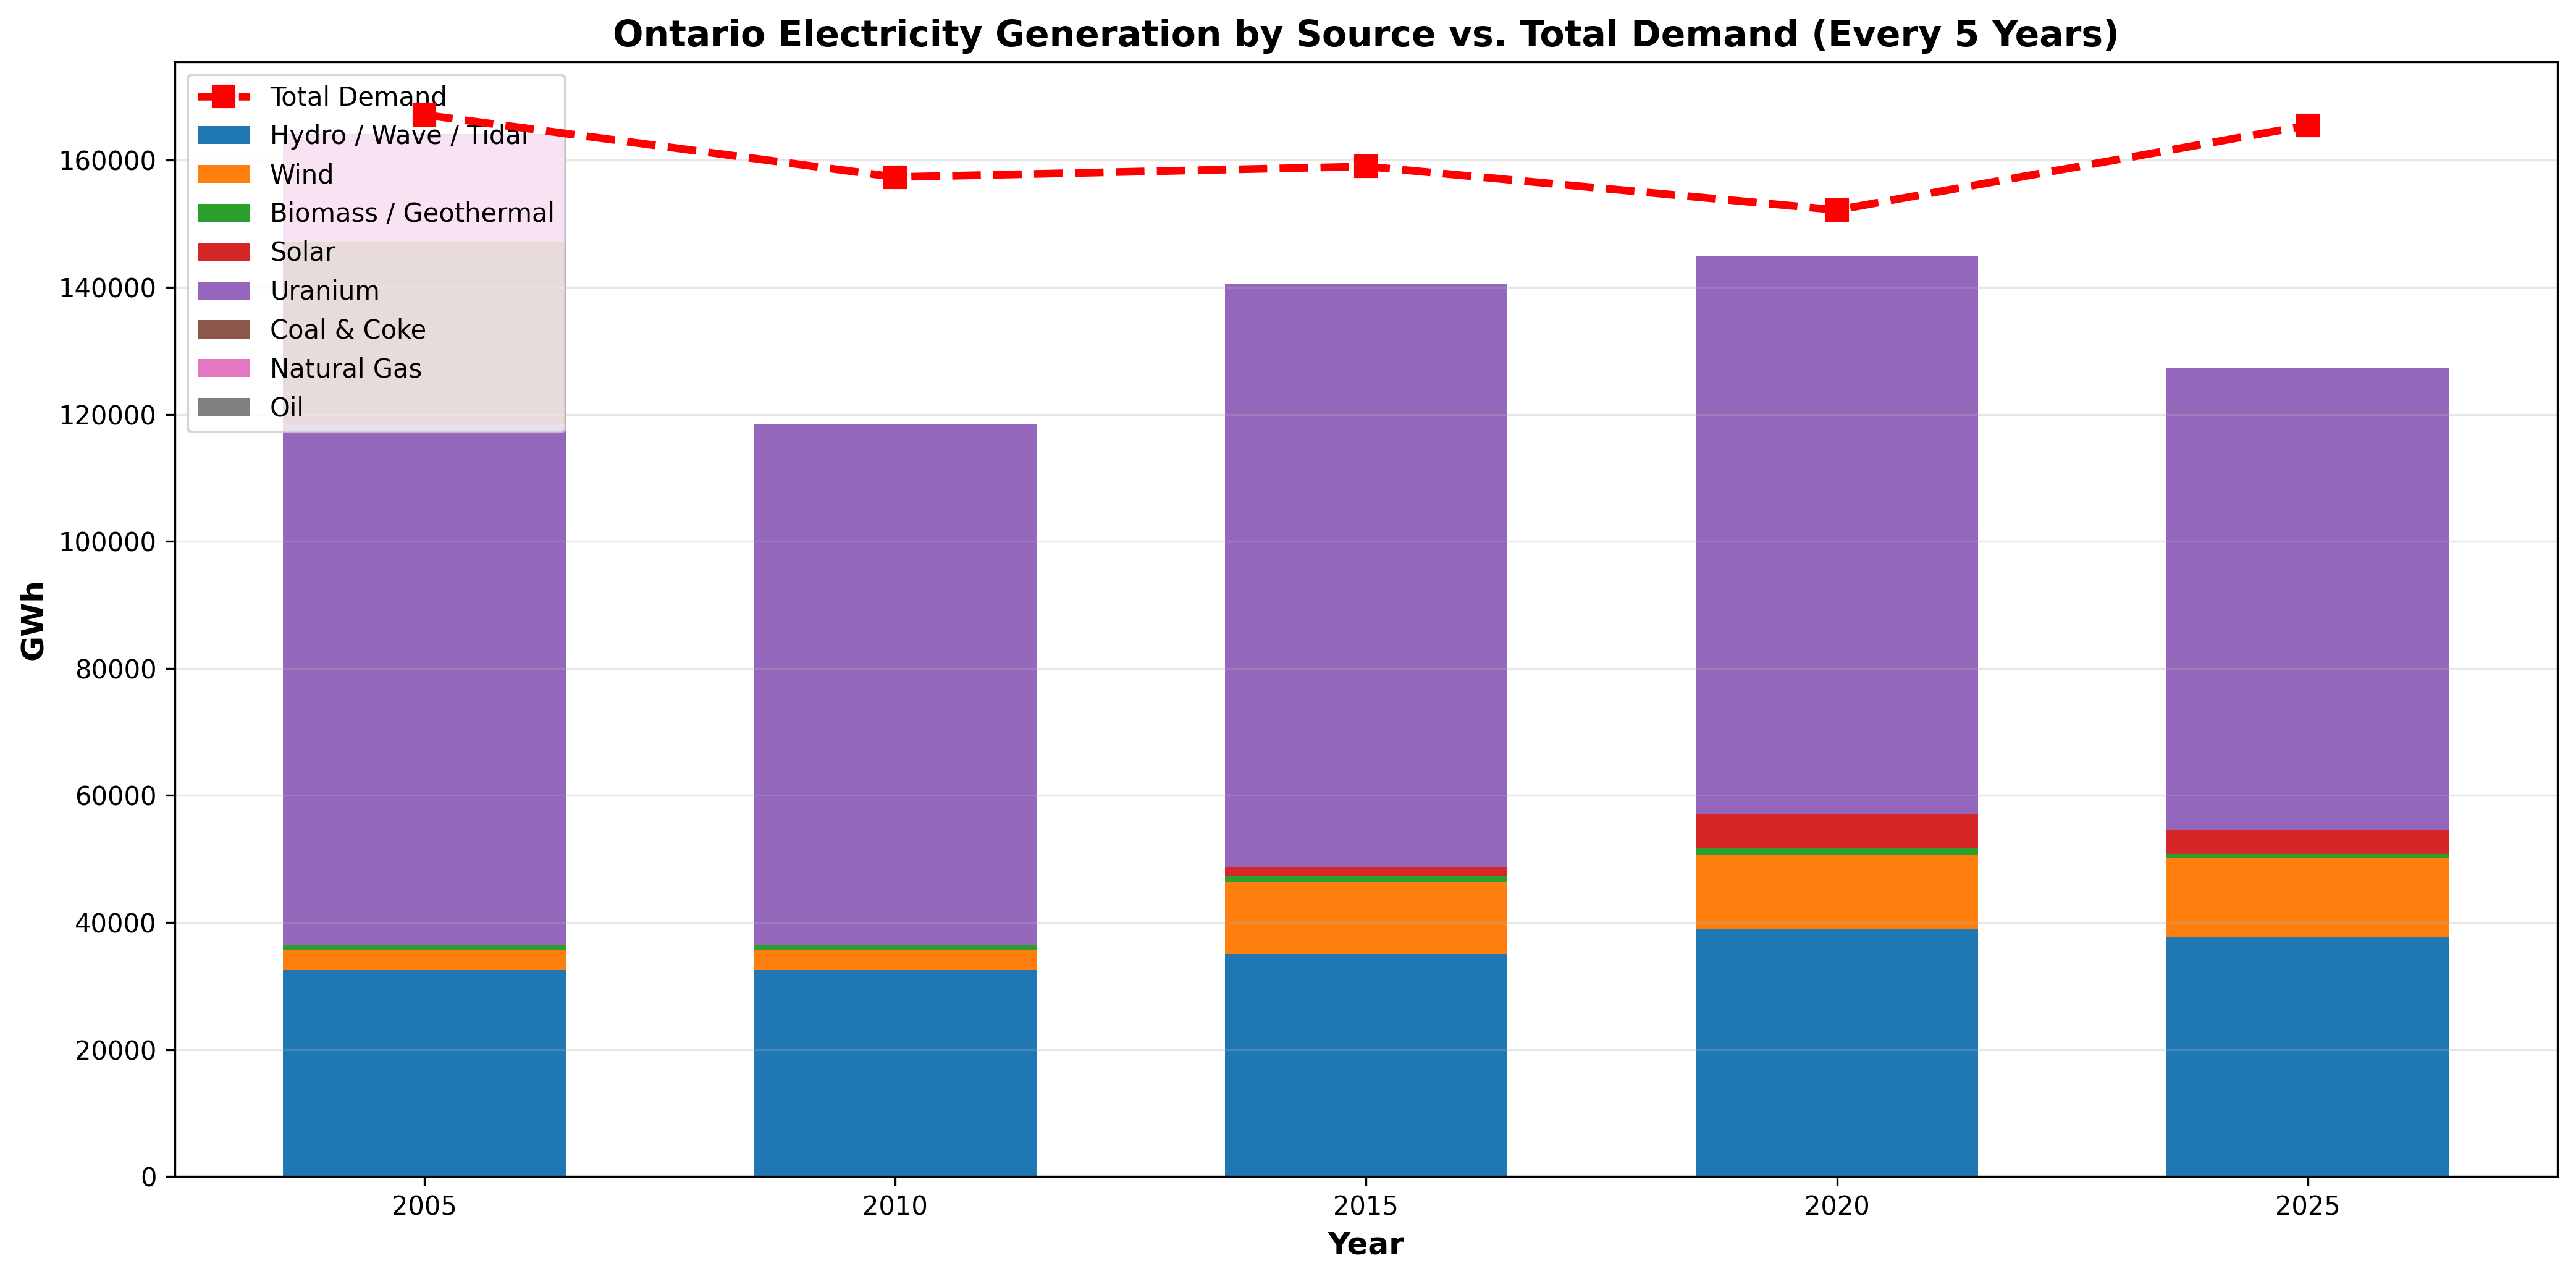


✓ Stacked bar chart with demand line saved


In [19]:
# Load demand data from yearly file
yearly_demand = pd.read_csv(data_folder / 'Yearly_Market_Demand_2002-2026.csv')
yearly_demand.columns = ['Year', 'Total_Demand']
yearly_demand['Total_Demand'] = yearly_demand['Total_Demand'] / 1000  # Convert to GWh

print("Yearly Demand:")
print(yearly_demand)

# Merge generation data with demand data
df_plot_t = df_plot.T.reset_index()
df_plot_t.columns.name = None
df_plot_t.columns = ['Year'] + list(df_plot.index)
df_plot_t['Year'] = df_plot_t['Year'].astype(int)

merged = df_plot_t.merge(yearly_demand, on='Year')
print("\nMerged data:")
print(merged)

# Filter for every 5 years
years_5yr = list(range(merged['Year'].min(), merged['Year'].max() + 1, 5))
if merged['Year'].max() not in years_5yr:
    years_5yr.append(merged['Year'].max())
    
merged_5yr = merged[merged['Year'].isin(years_5yr)].sort_values('Year')
# Exclude 2026
merged_5yr = merged_5yr[merged_5yr['Year'] != 2026]
print(f"\nEvery 5 years (excluding 2026): {years_5yr}")
print(merged_5yr)

# Create stacked bar chart with demand line
fig, ax = plt.subplots(figsize=(14, 7), dpi=300)

sources = [col for col in merged_5yr.columns if col not in ['Year', 'Total_Demand']]
x = range(len(merged_5yr))
bottom = None

for source in sources:
    if bottom is None:
        ax.bar(x, merged_5yr[source], label=source, width=0.6)
        bottom = merged_5yr[source].values.copy()
    else:
        ax.bar(x, merged_5yr[source], bottom=bottom, label=source, width=0.6)
        bottom = bottom + merged_5yr[source].values

# Add demand line on same axis
ax.plot(x, merged_5yr['Total_Demand'], color='red', marker='s', linewidth=3, 
        markersize=8, label='Total Demand', linestyle='--', zorder=10)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('GWh', fontsize=12, fontweight='bold')
ax.set_title('Ontario Electricity Generation by Source vs. Total Demand (Every 5 Years)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(merged_5yr['Year'].astype(int))

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
ax.legend(lines1, labels1, fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(data_folder / 'Electricity_Generation_Stacked_Bar_5yr.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Stacked bar chart with demand line saved")

Generation vs Demand Comparison (excluding 2026):
    Year  Total_Generation  Total_Demand  Difference  Percentage_Diff
0   2005         164147.00    167153.184   -3006.184            -1.80
1   2006         159221.00    162442.513   -3221.513            -1.98
2   2007         162881.64    164491.422   -1609.782            -0.98
3   2008         158051.13    170876.581  -12825.451            -7.51
4   2009         145874.07    154300.535   -8426.465            -5.46
5   2010         135412.92    157360.156  -21947.236           -13.95
6   2011         148028.05    154319.233   -6291.183            -4.08
7   2012         147195.14    155905.911   -8710.771            -5.59
8   2013         154560.92    158542.864   -3981.944            -2.51
9   2014         156168.48    158273.142   -2104.662            -1.33
10  2015         157446.55    159031.052   -1584.502            -1.00
11  2016         157038.24    158174.232   -1135.992            -0.72
12  2017         152641.61    150578.393

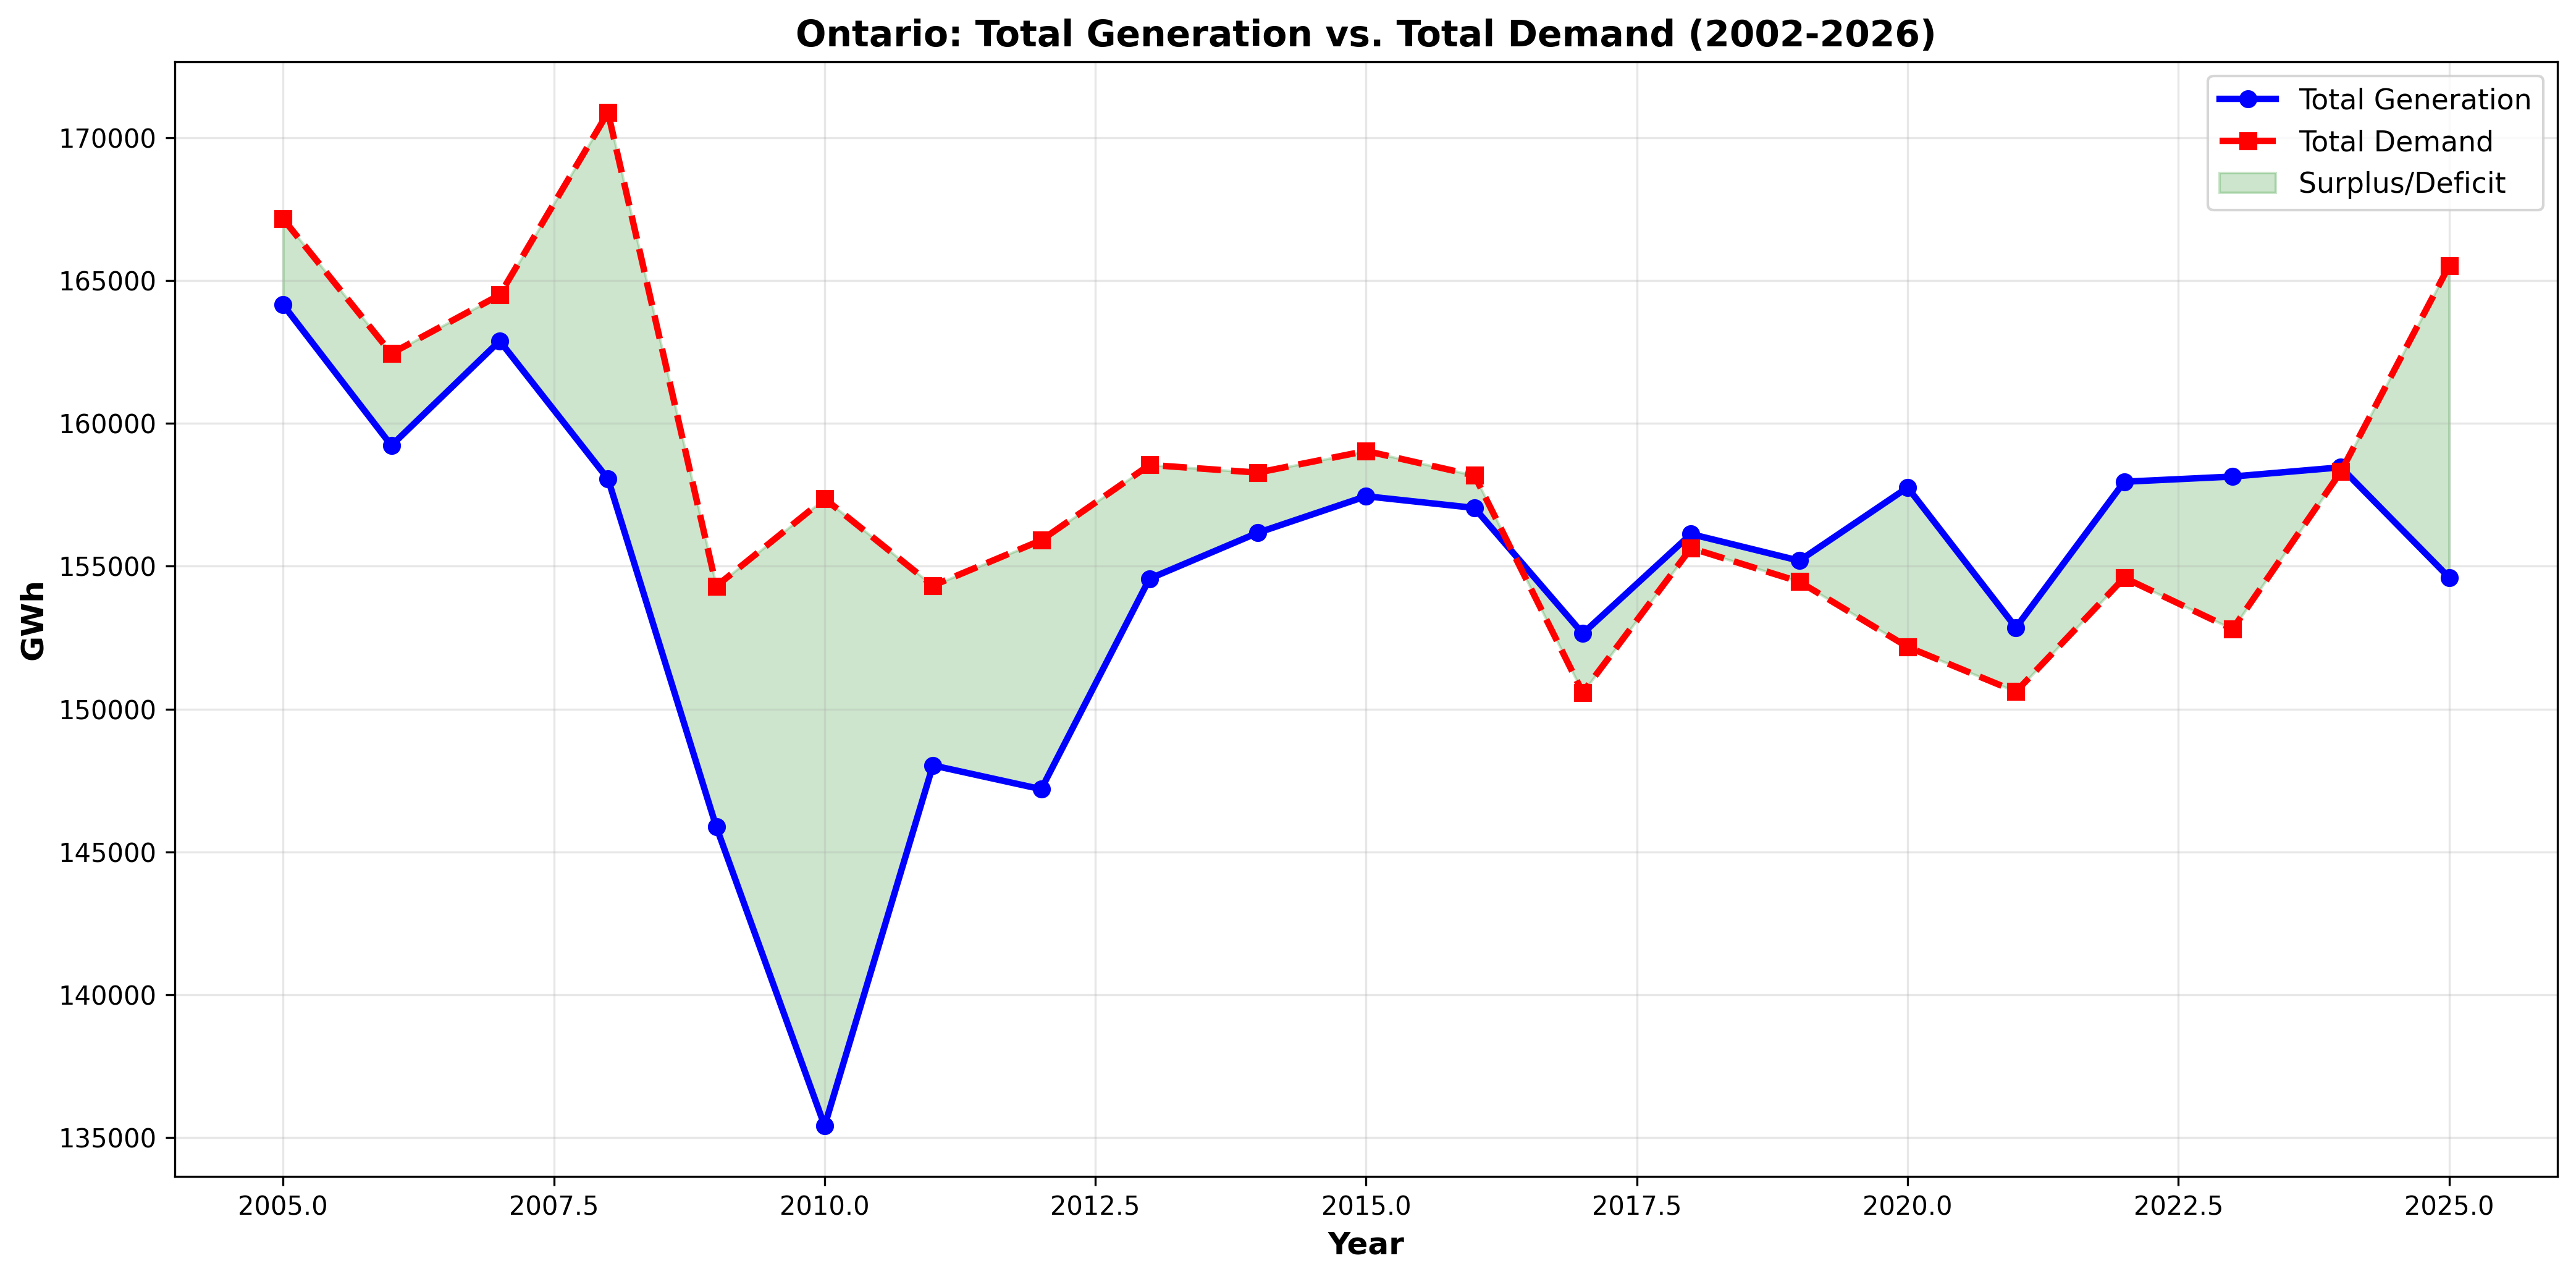


✓ Comparison chart saved


In [21]:
# Calculate total generation per year and compare to demand
df_plot_t_all = df_plot.T.reset_index()
df_plot_t_all.columns.name = None
df_plot_t_all.columns = ['Year'] + list(df_plot.index)
df_plot_t_all['Year'] = df_plot_t_all['Year'].astype(int)

# Calculate total generation
generation_sources = [col for col in df_plot_t_all.columns if col != 'Year']
df_plot_t_all['Total_Generation'] = df_plot_t_all[generation_sources].sum(axis=1)

# Merge with demand
yearly_demand_all = pd.read_csv(data_folder / 'Yearly_Market_Demand_2002-2026.csv')
yearly_demand_all.columns = ['Year', 'Total_Demand']
yearly_demand_all['Total_Demand'] = yearly_demand_all['Total_Demand'] / 1000  # Convert to GWh

comparison = df_plot_t_all[['Year', 'Total_Generation']].merge(yearly_demand_all, on='Year')
comparison['Difference'] = comparison['Total_Generation'] - comparison['Total_Demand']
comparison['Percentage_Diff'] = (comparison['Difference'] / comparison['Total_Demand'] * 100).round(2)

# Exclude 2026
comparison = comparison[comparison['Year'] != 2026]

print("Generation vs Demand Comparison (excluding 2026):")
print(comparison)
print(f"\nAverage difference: {comparison['Difference'].mean():.2f} GWh")
print(f"Min difference: {comparison['Difference'].min():.2f} GWh")
print(f"Max difference: {comparison['Difference'].max():.2f} GWh")

# Create comparison line graph
fig, ax = plt.subplots(figsize=(14, 7), dpi=300)

ax.plot(comparison['Year'], comparison['Total_Generation'], marker='o', linewidth=2.5, 
        markersize=6, label='Total Generation', color='blue')
ax.plot(comparison['Year'], comparison['Total_Demand'], marker='s', linewidth=2.5, 
        markersize=6, label='Total Demand', color='red', linestyle='--')
ax.fill_between(comparison['Year'], comparison['Total_Generation'], comparison['Total_Demand'], 
                alpha=0.2, color='green', label='Surplus/Deficit')

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('GWh', fontsize=12, fontweight='bold')
ax.set_title('Ontario: Total Generation vs. Total Demand (2002-2026)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_folder / 'Generation_vs_Demand_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comparison chart saved")